In [1]:
!gdown --id 1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r
!unzip -q Dataset_Evolutivo_Simulado.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r
From (redirected): https://drive.google.com/uc?id=1SSrcU-0Ph-ONr5r0qpr9V5ssF-OIVN2r&confirm=t&uuid=f5ef0d27-8ec9-4a43-a753-50417a4d44ba
To: /content/Dataset_Evolutivo_Simulado.zip
100% 627M/627M [00:09<00:00, 64.6MB/s]


Si el resultado anterior indica que se detectó una GPU, TensorFlow la utilizará automáticamente para el entrenamiento. Para monitorear la utilización de la GPU durante el entrenamiento, puedes abrir una terminal en Colab (Ctrl+`) y ejecutar `nvidia-smi`.

In [2]:
!pip list

Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
accelerate                               1.11.0
access                                   1.1.9
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.21.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                                    4.11.0
anywidget                          

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time
from tqdm import tqdm
import imageio

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [4]:
print("Paso 0: Verificando la disponibilidad de la GPU...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Se encontraron las siguientes GPUs: {gpus}")
    print("TensorFlow ha detectado y está utilizando la GPU.")
    # Puedes configurar el crecimiento de la memoria si tienes problemas de OOM
    # for gpu in gpus:
    #     tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No se encontraron GPUs. TensorFlow se ejecutará en CPU.")

print(f"¿Está TensorFlow usando una GPU? {tf.test.is_gpu_available()}")

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Paso 0: Verificando la disponibilidad de la GPU...
Se encontraron las siguientes GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow ha detectado y está utilizando la GPU.
¿Está TensorFlow usando una GPU? True


In [21]:
print("Paso 1: Definiendo parámetros...")
#Donde train_A es la etiqueta de estado temporal inicial y train_B es el estado temporal futuro que se espera como prediccion visual

PATH = 'Dataset_Evolutivo_Simulado/'
TRAIN_A_DIR = os.path.join(PATH, 'train_A')
TRAIN_B_DIR = os.path.join(PATH, 'train_B')

OUTPUT_IMG_DIR = 'Resultados_Entrenamiento'
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)

BUFFER_SIZE = 400
BATCH_SIZE = 8
IMG_WIDTH = 256
IMG_HEIGHT = 256
CHECKPOINT_INTERVAL = 15

EPOCHS = 200
LAMBDA = 100

Paso 1: Definiendo parámetros...


In [22]:
import os

print("Updating checkpoint directory to Google Drive...")
drive_checkpoint_dir = '/content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.3'
os.makedirs(drive_checkpoint_dir, exist_ok=True)
checkpoint_dir = drive_checkpoint_dir
print(f"Checkpoint directory updated to: {checkpoint_dir}")

print(f"Paso 0: Iniciando el bucle de entrenamiento por {EPOCHS} epochs...")
print(f"Los resultados se guardarán en: {OUTPUT_IMG_DIR}")
print(f"Los checkpoints se guardarán en: {checkpoint_dir}")

Updating checkpoint directory to Google Drive...
Checkpoint directory updated to: /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.3
Paso 0: Iniciando el bucle de entrenamiento por 200 epochs...
Los resultados se guardarán en: Resultados_Entrenamiento
Los checkpoints se guardarán en: /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.3


In [23]:
print("Paso 2: Definiendo funciones de carga de datos...")

def load_image(image_file):
    """Carga una imagen y la divide en T0 (entrada) y T1 (real)."""
    real_image_file = tf.strings.regex_replace(image_file, "train_A", "train_B")
    input_image = tf.io.read_file(image_file)
    input_image = tf.io.decode_jpeg(input_image, channels=3)
    real_image = tf.io.read_file(real_image_file)

    real_image = tf.io.decode_jpeg(real_image, channels=3)
    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)
    return input_image, real_image

Paso 2: Definiendo funciones de carga de datos...


In [24]:
def resize(input_image, real_image, height, width):
    """Redimensiona ambas imágenes."""
    input_image = tf.image.resize(input_image, [height, width],
                                  method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    real_image = tf.image.resize(real_image, [height, width],
                                 method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return input_image, real_image

In [25]:
def random_crop(input_image, real_image):
    """Recorte aleatorio a 256x256 (aumentación de datos)."""
    stacked_image = tf.stack([input_image, real_image], axis=0)
    cropped_image = tf.image.random_crop(
        stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])
    return cropped_image[0], cropped_image[1]

def normalize(input_image, real_image):
    """Normaliza las imágenes al rango [-1, 1]."""
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1
    return input_image, real_image

@tf.function()
def random_jitter(input_image, real_image):
    """Aumentación de datos estándar de Pix2Pix."""

    input_image, real_image = resize(input_image, real_image, 286, 286)

    input_image, real_image = random_crop(input_image, real_image)

    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        real_image = tf.image.flip_left_right(real_image)

    return input_image, real_image

def load_image_train(image_file):
    """Carga, aplica jitter y normaliza la imagen de entrenamiento."""
    input_image, real_image = load_image(image_file)
    input_image, real_image = random_jitter(input_image, real_image)
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image
def load_image_test(image_file):
    """Carga y normaliza una imagen de prueba (sin jitter)."""
    input_image, real_image = load_image(image_file)
    input_image, real_image = resize(input_image, real_image, IMG_HEIGHT, IMG_WIDTH)
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image

In [26]:
print("Paso 3: Creando pipeline de tf.data...")

train_files_pattern = os.path.join(TRAIN_A_DIR, '*.jpg')
num_train_files = len(glob.glob(train_files_pattern))

if num_train_files == 0:
    print(f"¡ADVERTENCIA! No se encontraron imágenes en: {train_files_pattern}")
    print("Asegúrate de haber ejecutado el script de preprocesamiento anterior.")
else:
    print(f"Total de pares de entrenamiento encontrados: {num_train_files}")

train_dataset = tf.data.Dataset.list_files(train_files_pattern)
train_dataset = train_dataset.map(load_image_train,
                                  num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.list_files(train_files_pattern)
test_dataset = test_dataset.take(10)
test_dataset = test_dataset.map(load_image_test)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

Paso 3: Creando pipeline de tf.data...
Total de pares de entrenamiento encontrados: 1863


In [27]:
print("Paso 4: Construyendo el Generador (U-Net)...")

def downsample(filters, size, apply_batchnorm=True):
    """Bloque de codificación (Downsampling) en U-Net."""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    """Bloque de decodificación (Upsampling) en U-Net."""
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(
        layers.Conv2DTranspose(filters, size, strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

def build_generator():
    """Construye el Generador U-Net completo."""
    inputs = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3])

    # Encoder
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]

    # Decoder
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4,
                                  strides=2,
                                  padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh')

    x = inputs


    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])


    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)

    return Model(inputs=inputs, outputs=x)

generator = build_generator()
#tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

Paso 4: Construyendo el Generador (U-Net)...


In [28]:
print("Paso 5: Construyendo el Discriminador (PatchGAN)...")

def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)


    inp = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3], name='input_image')



    tar = layers.Input(shape=[IMG_WIDTH, IMG_HEIGHT, 3], name='target_image')


    x = layers.concatenate([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)


    zero_pad1 = layers.ZeroPadding2D()(down3)
    conv = layers.Conv2D(512, 4, strides=1,
                          kernel_initializer=initializer,
                          use_bias=False)(zero_pad1)

    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)


    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(1, 4, strides=1,
                          kernel_initializer=initializer)(zero_pad2)


    return Model(inputs=[inp, tar], outputs=last)

discriminator = build_discriminator()
#tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

Paso 5: Construyendo el Discriminador (PatchGAN)...


In [29]:
print("Paso 6: Definiendo pérdidas y optimizadores...")

loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(disc_real_output, disc_generated_output):
    """Pérdida del Discriminador."""

    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)


    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss
    return total_disc_loss

def generator_loss(disc_generated_output, gen_output, target):
    """Pérdida del Generador."""

    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)


checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

Paso 6: Definiendo pérdidas y optimizadores...


In [34]:
print("Paso 6.5: Intentando cargar el último checkpoint...")

# Intenta restaurar el último checkpoint si existe
latest_ckpt = tf.train.latest_checkpoint(checkpoint_dir)
start_epoch = 0

if latest_ckpt:
    status = checkpoint.restore(latest_ckpt)
    status.expect_partial()


    try:
        ckpt_index = int(latest_ckpt.split('-')[-1])

        start_epoch = ckpt_index * CHECKPOINT_INTERVAL

        print(f" Checkpoint '{os.path.basename(latest_ckpt)}' restaurado exitosamente.")
        print(f"   - Índice del checkpoint: {ckpt_index}")
        print(f"   - Intervalo de guardado: cada {CHECKPOINT_INTERVAL} épocas")
        print(f"   - Reanudando entrenamiento desde la época: {start_epoch}")

    except ValueError:
        print(f"Advertencia: No se pudo deducir la época del nombre '{latest_ckpt}'.")
        print("   Se restauraron los pesos, pero 'start_epoch' se reiniciará a 0.")
else:
    print(" No se encontró ningún checkpoint previo.")
    print("   Iniciando entrenamiento desde cero (Época 0).")

Paso 6.5: Intentando cargar el último checkpoint...
 Checkpoint 'ckpt-13' restaurado exitosamente.
   - Índice del checkpoint: 13
   - Intervalo de guardado: cada 15 épocas
   - Reanudando entrenamiento desde la época: 195


In [35]:
print("Paso 7: Definiendo función de visualización...")

def generate_images(model, test_input, tar, epoch):
    """Genera y guarda una imagen de muestra."""
    prediction = model(test_input, training=True)

    plt.figure(figsize=(15, 5))

    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image (T0)', 'Ground Truth (T1)', 'Predicted Image (T_pred)']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')

    save_path = os.path.join(OUTPUT_IMG_DIR, f'image_at_epoch_{epoch:04d}.png')
    plt.savefig(save_path)
    plt.close()

Paso 7: Definiendo función de visualización...


In [36]:
print("Paso 8: Definiendo el paso de entrenamiento (Pix2Pix)...")
@tf.function
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

    return disc_loss, gen_total_loss, gen_gan_loss, gen_l1_loss

Paso 8: Definiendo el paso de entrenamiento (Pix2Pix)...


In [37]:
print("Paso 9: Iniciando el bucle de entrenamiento (Corregido)...")

def train(dataset, epochs, start_epoch):

    if num_train_files == 0:
        print("¡ERROR! No se encontraron imágenes en el directorio de entrenamiento.")
        return

    try:
        test_batch = next(iter(test_dataset))
    except StopIteration:
        print("¡ERROR! El dataset de prueba está vacío. No se puede generar imagen de muestra.")
        return

    seed_input, seed_target = test_batch
    print("Usando un lote de prueba fijo para generar imágenes de muestra.")

    for epoch in range(start_epoch, epochs):

        epoch_start_time = time.time()

        print(f"\nGenerando imagen de muestra para la época {epoch + 1}...")
        generate_images(generator, seed_input, seed_target, epoch)

        print(f"Iniciando Época {epoch + 1}/{epochs}")

        pbar = tqdm(total=num_train_files // BATCH_SIZE, desc=f"Época {epoch + 1}", unit="batch")

        epoch_disc_loss = []
        epoch_gen_total_loss = []
        epoch_gen_gan_loss = []
        epoch_gen_l1_loss = []

        for n, (input_image, target) in dataset.enumerate():


            disc_loss, gen_total_loss, gen_gan_loss, gen_l1_loss = train_step(input_image, target, epoch)


            epoch_disc_loss.append(disc_loss.numpy())
            epoch_gen_total_loss.append(gen_total_loss.numpy())
            epoch_gen_gan_loss.append(gen_gan_loss.numpy())
            epoch_gen_l1_loss.append(gen_l1_loss.numpy())

            pbar.update(1)
            if (n + 1) % 50 == 0:
                pbar.set_postfix_str(f"D_loss: {np.mean(epoch_disc_loss):.4f}, G_loss_total: {np.mean(epoch_gen_total_loss):.4f}")

        pbar.close()

        print(f"\n--- Resumen Época {epoch + 1} ---")
        print(f"Tiempo: {time.time() - epoch_start_time:.2f} seg")
        print(f"Pérdida Discriminador (Media): {np.mean(epoch_disc_loss):.4f}")
        print(f"Pérdida Generador (Total):     {np.mean(epoch_gen_total_loss):.4f}")
        print(f"Pérdida Generador (GAN):       {np.mean(epoch_gen_gan_loss):.4f}")
        print(f"Pérdida Generador (L1):        {np.mean(epoch_gen_l1_loss):.4f}")
        print("---------------------------\n")

        # Guardar Checkpoint
        if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
            checkpoint.save(file_prefix=os.path.join(checkpoint_dir, "ckpt"))
            print(f'Checkpoint guardado para la época {epoch + 1}')

    print(f"Generando imagen final del entrenamiento (Época {epochs})...")
    generate_images(generator, seed_input, seed_target, epochs)


Paso 9: Iniciando el bucle de entrenamiento (Corregido)...


In [38]:
print("Iniciando entrenamiento...")
train(train_dataset, EPOCHS, start_epoch)
print("Entrenamiento completado.")

Iniciando entrenamiento...
Usando un lote de prueba fijo para generar imágenes de muestra.

Generando imagen de muestra para la época 196...
Iniciando Época 196/200



Época 196: 100%|██████████| 232/232 [00:36<00:00,  9.77batch/s, D_loss: 0.6410, G_loss_total: 17.5245]
Época 196: 233batch [00:41,  5.65batch/s, D_loss: 0.6410, G_loss_total: 17.5245]



--- Resumen Época 196 ---
Tiempo: 41.76 seg
Pérdida Discriminador (Media): 0.6555
Pérdida Generador (Total):     17.5610
Pérdida Generador (GAN):       1.9841
Pérdida Generador (L1):        0.1558
---------------------------


Generando imagen de muestra para la época 197...
Iniciando Época 197/200



Época 197: 100%|██████████| 232/232 [00:29<00:00,  9.88batch/s, D_loss: 0.6578, G_loss_total: 17.4912]
Época 197: 233batch [00:34,  6.81batch/s, D_loss: 0.6578, G_loss_total: 17.4912]



--- Resumen Época 197 ---
Tiempo: 34.72 seg
Pérdida Discriminador (Media): 0.6646
Pérdida Generador (Total):     17.5904
Pérdida Generador (GAN):       2.0562
Pérdida Generador (L1):        0.1553
---------------------------


Generando imagen de muestra para la época 198...
Iniciando Época 198/200


...


--- Resumen Época 198 ---
Tiempo: 34.88 seg
Pérdida Discriminador (Media): 0.6368
Pérdida Generador (Total):     17.8172
Pérdida Generador (GAN):       2.0467
Pérdida Generador (L1):        0.1577
---------------------------


Generando imagen de muestra para la época 199...
Iniciando Época 199/200



Época 199: 100%|██████████| 232/232 [00:29<00:00,  9.84batch/s, D_loss: 0.6545, G_loss_total: 17.5507]
Época 199: 233batch [00:34,  6.82batch/s, D_loss: 0.6545, G_loss_total: 17.5507]



--- Resumen Época 199 ---
Tiempo: 34.65 seg
Pérdida Discriminador (Media): 0.6358
Pérdida Generador (Total):     17.6870
Pérdida Generador (GAN):       2.0721
Pérdida Generador (L1):        0.1561
---------------------------


Generando imagen de muestra para la época 200...
Iniciando Época 200/200



Época 200: 100%|██████████| 232/232 [00:29<00:00,  9.69batch/s, D_loss: 0.6800, G_loss_total: 17.6855]
Época 200: 233batch [00:34,  6.82batch/s, D_loss: 0.6800, G_loss_total: 17.6855]



--- Resumen Época 200 ---
Tiempo: 34.65 seg
Pérdida Discriminador (Media): 0.6725
Pérdida Generador (Total):     17.7067
Pérdida Generador (GAN):       2.1378
Pérdida Generador (L1):        0.1557
---------------------------

Generando imagen final del entrenamiento (Época 200)...
Entrenamiento completado.


In [39]:
print("Guardando el modelo generador en formato .keras...")

# Define la ruta para guardar el modelo
model_save_path = os.path.join(checkpoint_dir, 'generator_final.keras')

# Guarda el modelo en formato .keras
generator.save(model_save_path)

print(f"Modelo generador guardado exitosamente en: {model_save_path}")

Guardando el modelo generador en formato .keras...
Modelo generador guardado exitosamente en: /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.3/generator_final.keras


In [40]:
import tensorflow as tf
import os

print("Cargando el modelo generador desde formato .keras...")

model_load_path = os.path.join(checkpoint_dir, 'generator_final.keras')

# Carga el modelo
try:
    loaded_generator = tf.keras.models.load_model(model_load_path)
    print(f"Modelo generador cargado exitosamente desde: {model_load_path}")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")

Cargando el modelo generador desde formato .keras...
Modelo generador cargado exitosamente desde: /content/drive/MyDrive/Upao/9Ciclo/DeepLearning/Proyecto/training/Checkpoint-GAN-Simple-1.3/generator_final.keras


Probando predicción con la imagen: Dataset_Evolutivo_Simulado/train_A/HAM_0002534_ISIC_0029538.jpg


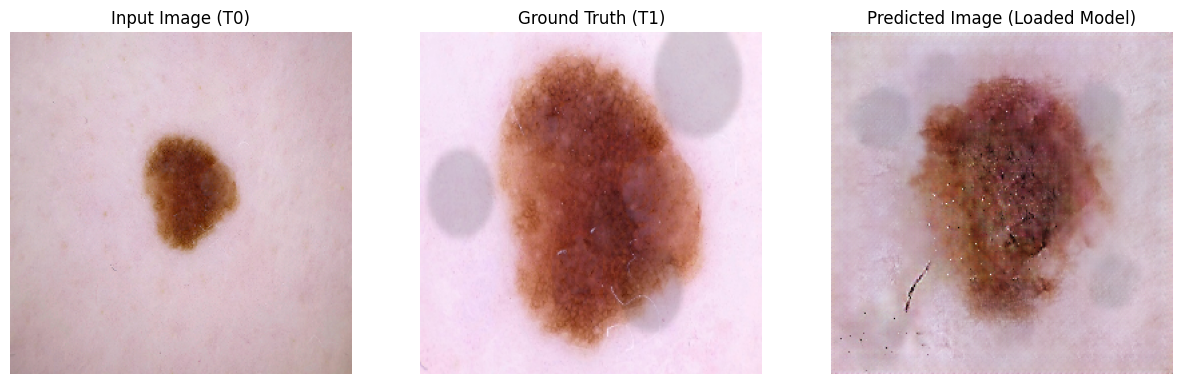

In [44]:
def predict_sample(model, image_path):
    """Genera una predicción utilizando el modelo cargado y muestra los resultados."""

    # Cargar y preprocesar la imagen usando las funciones definidas anteriormente
    # Nota: load_image espera un tensor o string path, y busca la pareja en train_B
    input_img, real_img = load_image(image_path)

    # Redimensionar a 256x256
    input_img, real_img = resize(input_img, real_img, IMG_HEIGHT, IMG_WIDTH)

    # Normalizar a [-1, 1]
    input_img, real_img = normalize(input_img, real_img)

    # Expandir dimensiones para crear un lote de tamaño 1 (1, 256, 256, 3)
    input_batch = tf.expand_dims(input_img, 0)

    # Generar predicción
    # training=True es usual en Pix2Pix inference si se quiere mantener Dropout (si lo hubiera)
    prediction = model(input_batch, training=True)

    # Visualización
    plt.figure(figsize=(15, 5))
    display_list = [input_img, real_img, prediction[0]]
    title = ['Input Image (T0)', 'Ground Truth (T1)', 'Predicted Image (Loaded Model)']

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

# --- Prueba con una imagen aleatoria del directorio de entrenamiento ---
import random

sample_files = glob.glob(os.path.join(TRAIN_A_DIR, '*.jpg'))

if sample_files:
    random_file = random.choice(sample_files)
    print(f"Probando predicción con la imagen: {random_file}")
    predict_sample(loaded_generator, random_file)
else:
    print("No se encontraron imágenes en el directorio para probar.")